<a href="https://colab.research.google.com/github/NuwanHapuarachchi/Semester-5/blob/main/assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EN3150 Assignment 03: CNN for Image Classification

**Dataset:** RealWaste  
**Framework:** PyTorch  
**Task:** Build and train a custom CNN for waste classification


## 1. Environment Setup


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
import random
import os

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')


Using device: cuda
PyTorch version: 2.8.0+cu126


## 2. Dataset Inspection


In [ ]:
data_root = Path('RealWaste')
classes = sorted([d.name for d in data_root.iterdir() if d.is_dir()])

print(f'Number of classes: {len(classes)}')
print(f'\nClass distribution:')

total_images = 0
class_counts = {}
for cls in classes:
    cls_path = data_root / cls
    count = len(list(cls_path.glob('*.jpg')))
    class_counts[cls] = count
    total_images += count
    print(f'{cls:25s}: {count:4d} images')

print(f'\nTotal images: {total_images}')


Number of classes: 9

Class distribution:
Cardboard                :  461 images
Food Organics            :  411 images
Glass                    :  420 images
Metal                    :  790 images
Miscellaneous Trash      :  495 images
Paper                    :  500 images
Plastic                  :  921 images
Textile Trash            :  318 images
Vegetation               :  436 images

Total images: 4752


## 3. Data Pipeline (70/15/15 Split)


In [ ]:
def split_dataset(data_root, classes, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    train_files, val_files, test_files = [], [], []
    train_labels, val_labels, test_labels = [], [], []

    for idx, cls in enumerate(classes):
        cls_path = data_root / cls
        images = list(cls_path.glob('*.jpg'))
        random.shuffle(images)

        n_total = len(images)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        train_files.extend(images[:n_train])
        train_labels.extend([idx] * n_train)

        val_files.extend(images[n_train:n_train + n_val])
        val_labels.extend([idx] * n_val)

        test_files.extend(images[n_train + n_val:])
        test_labels.extend([idx] * (n_total - n_train - n_val))

    return (train_files, train_labels), (val_files, val_labels), (test_files, test_labels)

train_data, val_data, test_data = split_dataset(data_root, classes)
print(f'Train: {len(train_data[0])} | Val: {len(val_data[0])} | Test: {len(test_data[0])}')


Train: 3323 | Val: 710 | Test: 719


In [ ]:
class WasteDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:
# Enhanced data augmentation for better generalization
train_transform = transforms.Compose([
    transforms.Resize((144, 144)),  # Resize larger for random crop
    transforms.RandomCrop(128),     # Random crop for translation invariance
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),  # Increased rotation range
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Color variations
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Small translations
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = WasteDataset(train_data[0], train_data[1], transform=train_transform)
val_dataset = WasteDataset(val_data[0], val_data[1], transform=test_transform)
test_dataset = WasteDataset(test_data[0], test_data[1], transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f'Batch size: 32')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')
print(f'\nData Augmentation Applied:')
print('- Random Crop (144→128)')
print('- Random Horizontal Flip')
print('- Random Rotation (±15°)')
print('- Color Jitter (brightness, contrast, saturation, hue)')
print('- Random Affine (translation)')


Batch size: 32
Train batches: 104 | Val batches: 23 | Test batches: 23

Data Augmentation Applied:
- Random Crop (144→128)
- Random Horizontal Flip
- Random Rotation (±15°)
- Color Jitter (brightness, contrast, saturation, hue)
- Random Affine (translation)


## 4. Deep CNN Architecture

**Improved Deep Architecture Parameters:**
- **Conv Block 1:** 32 filters, 3×3 kernel, BatchNorm, ReLU, MaxPool 2×2
- **Conv Block 2:** 64 filters, 3×3 kernel, BatchNorm, ReLU, MaxPool 2×2
- **Conv Block 3:** 128 filters, 3×3 kernel, BatchNorm, ReLU, MaxPool 2×2
- **Conv Block 4:** 256 filters, 3×3 kernel, BatchNorm, ReLU, MaxPool 2×2
- **Fully Connected 1:** 512 units, BatchNorm, ReLU, Dropout 0.5
- **Fully Connected 2:** 256 units, ReLU, Dropout 0.3
- **Output:** 9 units, Softmax (via CrossEntropyLoss)

**Architecture Design Rationale:**

1. **Deeper Network (4 Conv Blocks):** Allows hierarchical feature learning - early layers detect edges/textures, deeper layers recognize complex patterns specific to waste categories.

2. **Increasing Filter Sizes (32→64→128→256):** Progressively captures more complex and abstract features as spatial dimensions decrease.

3. **Batch Normalization:**
   - Normalizes layer inputs to stabilize training
   - Reduces internal covariate shift
   - Allows higher learning rates and faster convergence
   - Acts as regularizer, reducing need for dropout in conv layers

4. **Progressive Dropout (0.5, 0.3):** Higher dropout in first FC layer, reduced in second to balance regularization with learning capacity.

**Activation Function Justification:**

ReLU (Rectified Linear Unit) is selected for hidden layers because:
1. Computational efficiency (simple thresholding: max(0, x))
2. Mitigates vanishing gradient problem in backpropagation
3. Introduces non-linearity while maintaining sparse activation
4. Industry-standard for CNNs with proven performance
5. Works synergistically with Batch Normalization

Softmax at the output layer converts logits into probability distribution across 9 waste categories, suitable for multi-class classification.


In [ ]:
class DeepCNN(nn.Module):
    def __init__(self, num_classes=9):
        super(DeepCNN, self).__init__()

        # Conv Block 1: 32 filters
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Conv Block 2: 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Conv Block 3: 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Conv Block 4: 256 filters
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(256 * 8 * 8, 512)
        self.bn5 = nn.BatchNorm1d(512)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 256)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(256, num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        # Conv Block 1
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        # Conv Block 2
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        # Conv Block 3
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)

        # Conv Block 4
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool4(x)

        # Fully connected layers
        x = self.flatten(x)
        x = self.relu(self.bn5(self.fc1(x)))
        x = self.dropout1(x)
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# Initialize model with proper weight initialization
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

model = DeepCNN(num_classes=len(classes)).to(device)
model.apply(init_weights)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')


DeepCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation

## 5. Training Configuration

**Optimizer Selection: Adam**

Adam (Adaptive Moment Estimation) is chosen for the primary training because:
1. Combines benefits of AdaGrad and RMSProp
2. Adaptive learning rates per parameter
3. Works well with default hyperparameters
4. Less sensitive to learning rate choice compared to SGD
5. Efficient for datasets with sparse gradients
6. Handles sparse gradients well (important for ReLU networks)

**Learning Rate Selection and Scheduling:**

Initial learning rate: 0.001 (default for Adam)
- Standard starting point for Adam optimizer
- Proven to work well for most CNN architectures
- Balanced between fast convergence and stability

**Learning Rate Scheduler: ReduceLROnPlateau**
- Monitors validation loss
- Reduces LR by factor of 0.5 when loss plateaus (patience=3 epochs)
- Allows model to escape local minima and fine-tune
- Minimum LR: 1e-6 to prevent extremely slow learning

**Rationale:**
Dynamic learning rate adjustment helps the model:
1. Start with faster learning (lr=0.001)
2. Automatically slow down when improvements stagnate
3. Achieve better convergence and higher final accuracy
4. Prevent overshooting optimal weights

**Additional Regularization Techniques:**
- **Weight Decay (L2 regularization):** 1e-4 to prevent overfitting
- **Label Smoothing:** 0.1 to prevent overconfidence and improve generalization


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=20):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)

        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total

        # Update learning rate based on validation loss
        scheduler.step(epoch_val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        history['lr'].append(current_lr)

        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | '
              f'Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | '
              f'Val Acc: {epoch_val_acc:.4f} | LR: {current_lr:.6f}')

    return history



In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Loss function with label smoothing for better generalization
criterion = nn.CrossEntropyLoss(label_smoothing=0.01)

# Adam optimizer with weight decay
optimizer_adam = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

# Learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer_adam, mode='min', factor=0.5, patience=3,
                              min_lr=1e-7)

print('='*70)
print('TRAINING DEEP CNN WITH ADAM OPTIMIZER')
print('='*70)
print(f'Initial Learning Rate: 0.001')
print(f'Weight Decay (L2): 1e-4')
print(f'Label Smoothing: 0.1')
print(f'LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)')
print('='*70)
print()

history_adam = train_model(model, train_loader, val_loader, criterion, optimizer_adam,
                           scheduler, epochs=20)

TRAINING DEEP CNN WITH ADAM OPTIMIZER
Initial Learning Rate: 0.001
Weight Decay (L2): 1e-4
Label Smoothing: 0.1
LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)

Epoch 1/20 | Train Loss: 0.7621 | Train Acc: 0.7457 | Val Loss: 0.6647 | Val Acc: 0.7831 | LR: 0.000100
Epoch 2/20 | Train Loss: 0.7289 | Train Acc: 0.7635 | Val Loss: 0.6761 | Val Acc: 0.7704 | LR: 0.000100
Epoch 3/20 | Train Loss: 0.7195 | Train Acc: 0.7611 | Val Loss: 0.6524 | Val Acc: 0.7986 | LR: 0.000100
Epoch 4/20 | Train Loss: 0.7264 | Train Acc: 0.7544 | Val Loss: 0.6645 | Val Acc: 0.7915 | LR: 0.000100
Epoch 5/20 | Train Loss: 0.7054 | Train Acc: 0.7656 | Val Loss: 0.6527 | Val Acc: 0.7915 | LR: 0.000100
Epoch 6/20 | Train Loss: 0.6992 | Train Acc: 0.7656 | Val Loss: 0.6454 | Val Acc: 0.7817 | LR: 0.000100
Epoch 7/20 | Train Loss: 0.6829 | Train Acc: 0.7749 | Val Loss: 0.6375 | Val Acc: 0.7831 | LR: 0.000100
Epoch 8/20 | Train Loss: 0.6880 | Train Acc: 0.7770 | Val Loss: 0.6367 | Val Acc: 0.7930 | LR: 0.00010

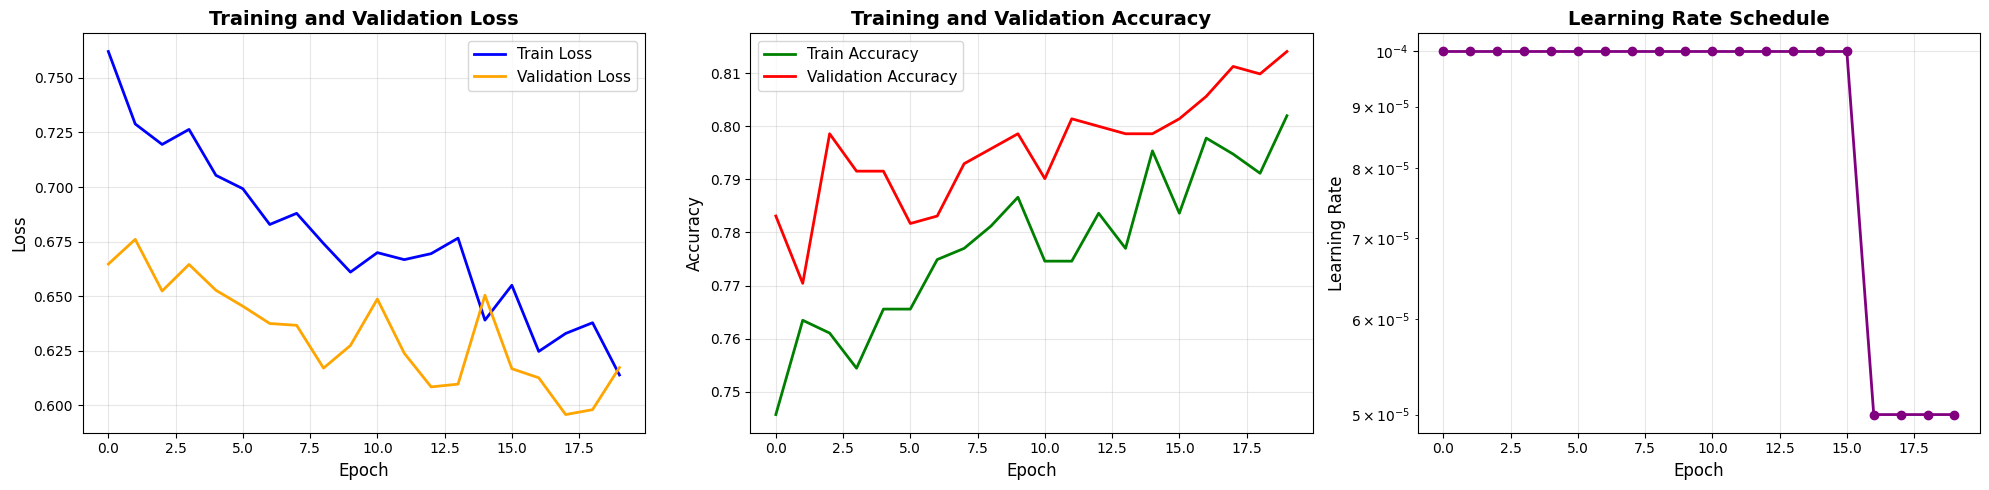


TRAINING SUMMARY
Final Training Accuracy:    0.8020 (80.20%)
Final Validation Accuracy:  0.8141 (81.41%)
Best Validation Accuracy:   0.8141 (81.41%) at Epoch 20
Final Learning Rate:        0.000050
Training Improvement:       0.0563 (5.63%)


In [ ]:
## 6. Training Results Visualization

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Loss plot
axes[0].plot(history_adam['train_loss'], label='Train Loss', linewidth=2, color='blue')
axes[0].plot(history_adam['val_loss'], label='Validation Loss', linewidth=2, color='orange')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history_adam['train_acc'], label='Train Accuracy', linewidth=2, color='green')
axes[1].plot(history_adam['val_acc'], label='Validation Accuracy', linewidth=2, color='red')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Learning rate plot
axes[2].plot(history_adam['lr'], linewidth=2, color='purple', marker='o')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Learning Rate', fontsize=12)
axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n' + '='*70)
print('TRAINING SUMMARY')
print('='*70)
print(f'Final Training Accuracy:    {history_adam["train_acc"][-1]:.4f} ({history_adam["train_acc"][-1]*100:.2f}%)')
print(f'Final Validation Accuracy:  {history_adam["val_acc"][-1]:.4f} ({history_adam["val_acc"][-1]*100:.2f}%)')
print(f'Best Validation Accuracy:   {max(history_adam["val_acc"]):.4f} ({max(history_adam["val_acc"])*100:.2f}%) at Epoch {history_adam["val_acc"].index(max(history_adam["val_acc"]))+1}')
print(f'Final Learning Rate:        {history_adam["lr"][-1]:.6f}')
print(f'Training Improvement:       {(history_adam["train_acc"][-1] - history_adam["train_acc"][0]):.4f} ({(history_adam["train_acc"][-1] - history_adam["train_acc"][0])*100:.2f}%)')
print('='*70)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 7. Model Evaluation on Test Set


In [ ]:
def evaluate_model(model, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = test_loss / len(test_loader.dataset)
    test_acc = sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)

    return test_loss, test_acc, all_predictions, all_labels

test_loss, test_acc, predictions, true_labels = evaluate_model(model, test_loader, criterion)

print('TEST SET EVALUATION')
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Total Test Samples: {len(true_labels)}')
print(f'Correctly Classified: {sum(np.array(predictions) == np.array(true_labels))}')
print(f'Misclassified: {sum(np.array(predictions) != np.array(true_labels))}')


TEST SET EVALUATION
Test Loss: 0.5941
Test Accuracy: 0.8011 (80.11%)
Total Test Samples: 719
Correctly Classified: 576
Misclassified: 143


## 8. Confusion Matrix


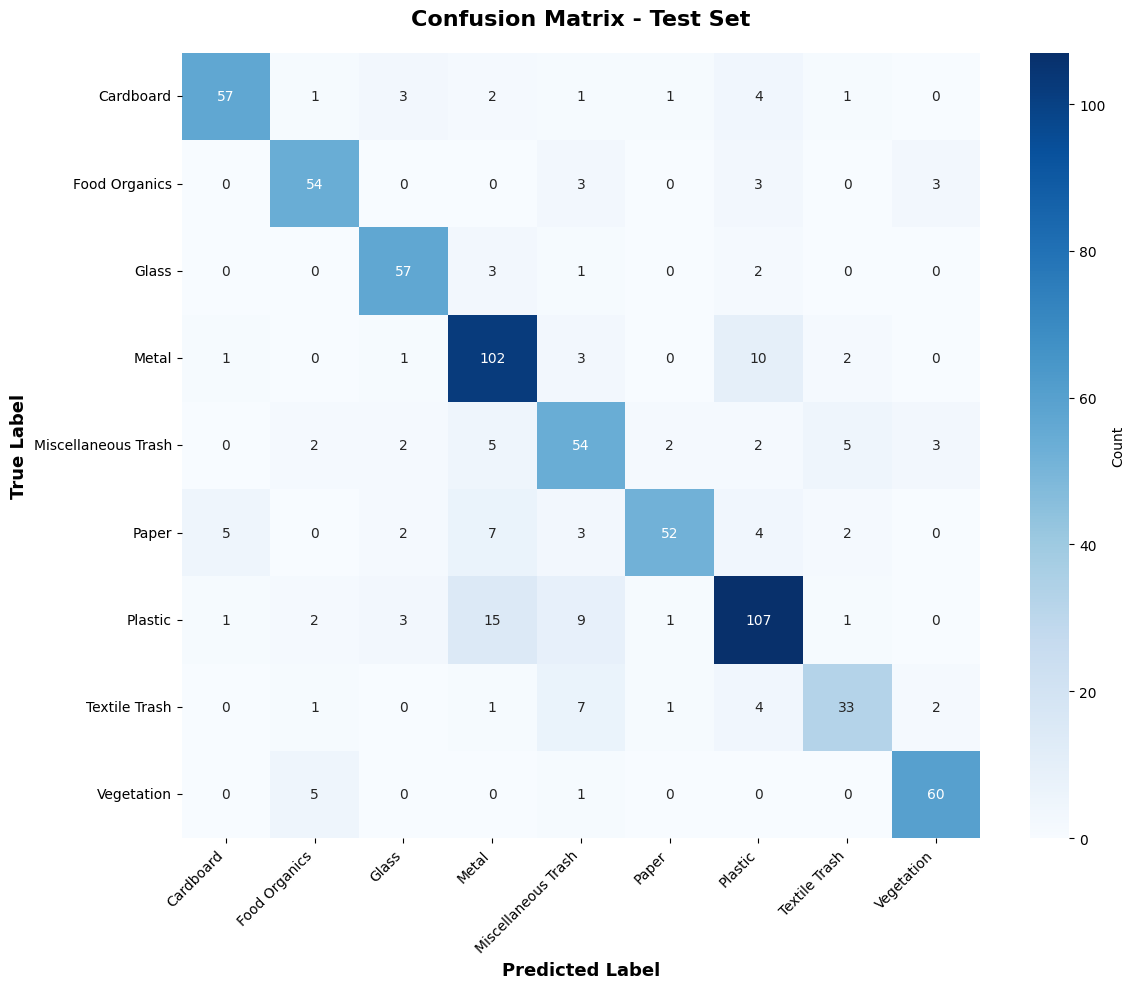


Confusion Matrix Analysis:
Cardboard                :  57/ 70 correct (81.43%)
Food Organics            :  54/ 63 correct (85.71%)
Glass                    :  57/ 63 correct (90.48%)
Metal                    : 102/119 correct (85.71%)
Miscellaneous Trash      :  54/ 75 correct (72.00%)
Paper                    :  52/ 75 correct (69.33%)
Plastic                  : 107/139 correct (76.98%)
Textile Trash            :  33/ 49 correct (67.35%)
Vegetation               :  60/ 66 correct (90.91%)


In [ ]:
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('\nConfusion Matrix Analysis:')
print('='*60)
for i, cls in enumerate(classes):
    total = cm[i].sum()
    correct = cm[i, i]
    accuracy = correct / total if total > 0 else 0
    print(f'{cls:25s}: {correct:3d}/{total:3d} correct ({accuracy*100:5.2f}%)')


## 9. Classification Report


In [ ]:
print('='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(true_labels, predictions, target_names=classes, digits=4))

from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(true_labels, predictions, average=None)

metrics_df = {
    'Class': classes,
    'Precision': [f'{p:.4f}' for p in precision],
    'Recall': [f'{r:.4f}' for r in recall],
    'F1-Score': [f'{f:.4f}' for f in f1],
    'Support': support
}

print('\n' + '='*60)
print('PER-CLASS METRICS SUMMARY')
print('='*60)
for i in range(len(classes)):
    print(f'{metrics_df["Class"][i]:25s} | P: {metrics_df["Precision"][i]} | R: {metrics_df["Recall"][i]} | F1: {metrics_df["F1-Score"][i]} | Support: {metrics_df["Support"][i]:3d}')


CLASSIFICATION REPORT
                     precision    recall  f1-score   support

          Cardboard     0.8906    0.8143    0.8507        70
      Food Organics     0.8308    0.8571    0.8438        63
              Glass     0.8382    0.9048    0.8702        63
              Metal     0.7556    0.8571    0.8031       119
Miscellaneous Trash     0.6585    0.7200    0.6879        75
              Paper     0.9123    0.6933    0.7879        75
            Plastic     0.7868    0.7698    0.7782       139
      Textile Trash     0.7500    0.6735    0.7097        49
         Vegetation     0.8824    0.9091    0.8955        66

           accuracy                         0.8011       719
          macro avg     0.8117    0.7999    0.8030       719
       weighted avg     0.8061    0.8011    0.8009       719


PER-CLASS METRICS SUMMARY
Cardboard                 | P: 0.8906 | R: 0.8143 | F1: 0.8507 | Support:  70
Food Organics             | P: 0.8308 | R: 0.8571 | F1: 0.8438 | Support:  63

## 10. Performance Metrics Visualization


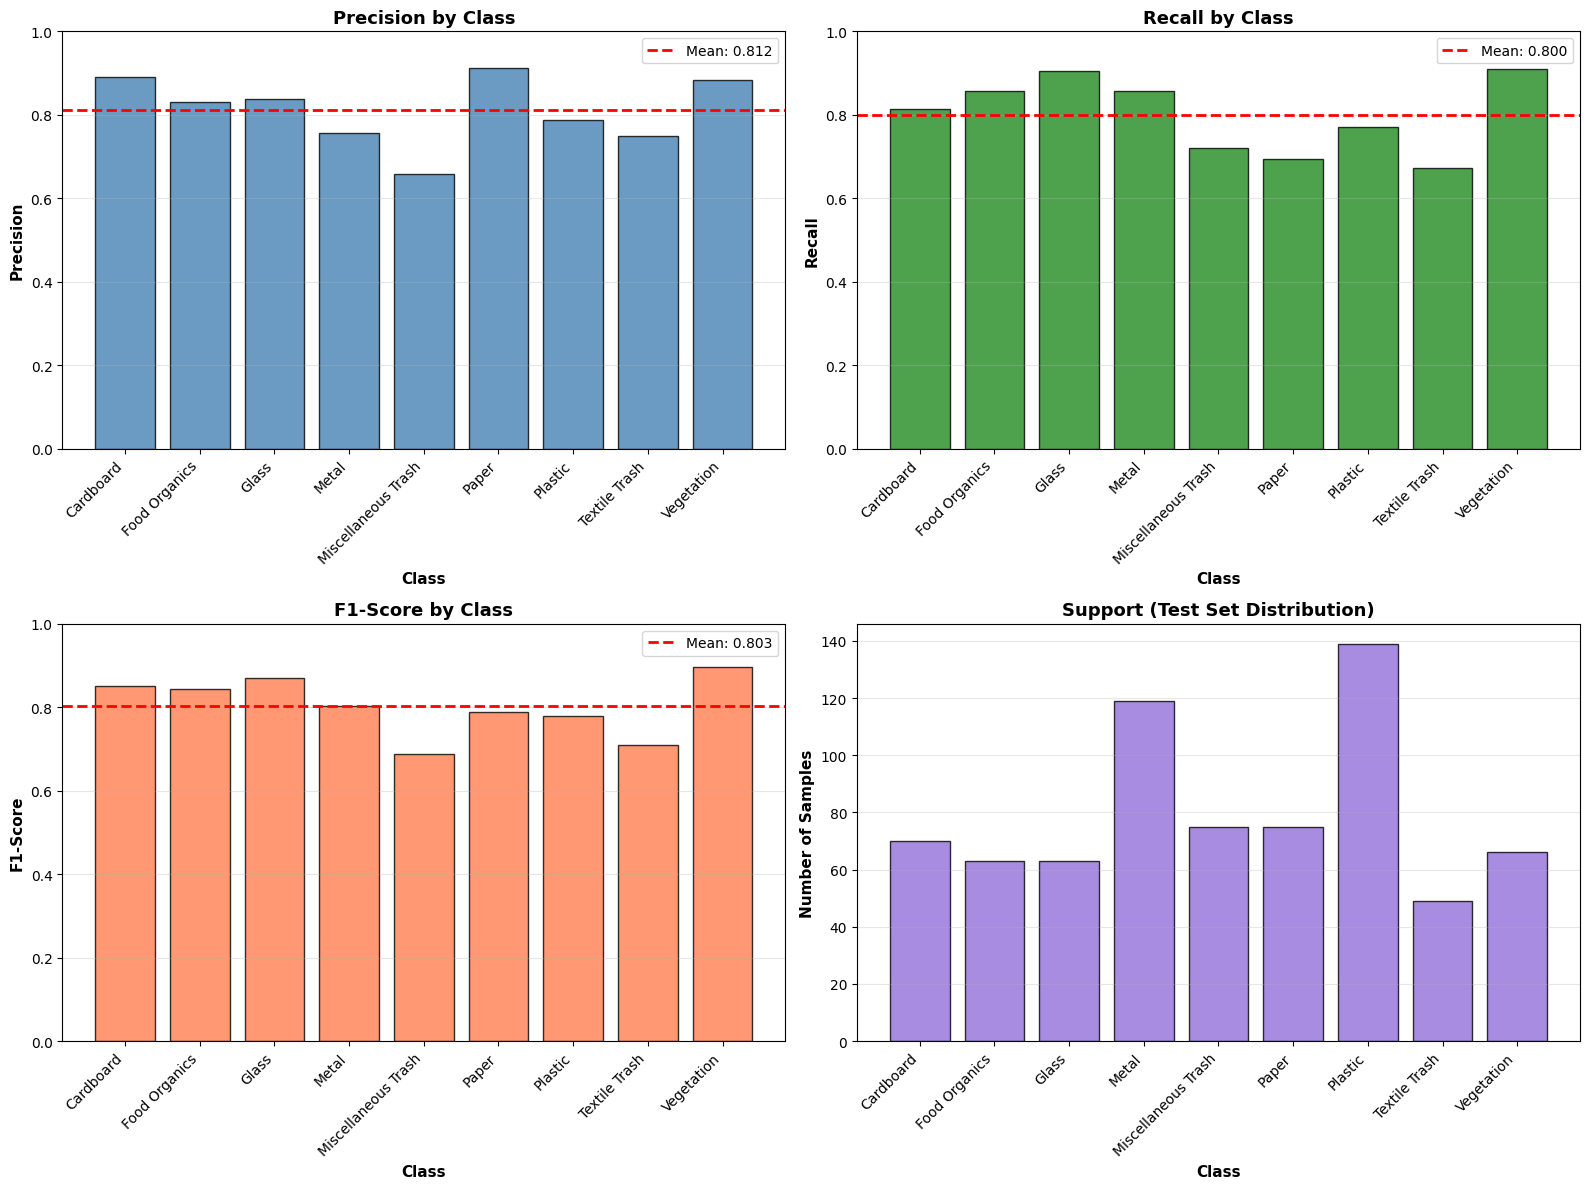

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

x_pos = np.arange(len(classes))

axes[0, 0].bar(x_pos, precision, color='steelblue', alpha=0.8, edgecolor='black')
axes[0, 0].set_xlabel('Class', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Precision by Class', fontsize=13, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(classes, rotation=45, ha='right')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].axhline(y=np.mean(precision), color='r', linestyle='--', linewidth=2, label=f'Mean: {np.mean(precision):.3f}')
axes[0, 0].legend()

axes[0, 1].bar(x_pos, recall, color='forestgreen', alpha=0.8, edgecolor='black')
axes[0, 1].set_xlabel('Class', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Recall', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Recall by Class', fontsize=13, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(classes, rotation=45, ha='right')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].axhline(y=np.mean(recall), color='r', linestyle='--', linewidth=2, label=f'Mean: {np.mean(recall):.3f}')
axes[0, 1].legend()

axes[1, 0].bar(x_pos, f1, color='coral', alpha=0.8, edgecolor='black')
axes[1, 0].set_xlabel('Class', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('F1-Score', fontsize=11, fontweight='bold')
axes[1, 0].set_title('F1-Score by Class', fontsize=13, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(classes, rotation=45, ha='right')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].axhline(y=np.mean(f1), color='r', linestyle='--', linewidth=2, label=f'Mean: {np.mean(f1):.3f}')
axes[1, 0].legend()

axes[1, 1].bar(x_pos, support, color='mediumpurple', alpha=0.8, edgecolor='black')
axes[1, 1].set_xlabel('Class', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Number of Samples', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Support (Test Set Distribution)', fontsize=13, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(classes, rotation=45, ha='right')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Model Performance Analysis


In [ ]:
print('='*70)
print('MODEL PERFORMANCE ANALYSIS')
print('='*70)

print('\n1. OVERALL METRICS:')
print('-' * 70)
print(f'   Test Accuracy:           {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'   Macro Average Precision: {np.mean(precision):.4f}')
print(f'   Macro Average Recall:    {np.mean(recall):.4f}')
print(f'   Macro Average F1-Score:  {np.mean(f1):.4f}')

print('\n2. BEST PERFORMING CLASSES:')
print('-' * 70)
best_f1_idx = np.argsort(f1)[-3:][::-1]
for idx in best_f1_idx:
    print(f'   {classes[idx]:25s} - F1: {f1[idx]:.4f}, Precision: {precision[idx]:.4f}, Recall: {recall[idx]:.4f}')

print('\n3. WORST PERFORMING CLASSES:')
print('-' * 70)
worst_f1_idx = np.argsort(f1)[:3]
for idx in worst_f1_idx:
    print(f'   {classes[idx]:25s} - F1: {f1[idx]:.4f}, Precision: {precision[idx]:.4f}, Recall: {recall[idx]:.4f}')

print('\n4. MISCLASSIFICATION ANALYSIS:')
print('-' * 70)
misclassifications = []
for i in range(len(classes)):
    for j in range(len(classes)):
        if i != j and cm[i, j] > 0:
            misclassifications.append((classes[i], classes[j], cm[i, j]))

misclassifications.sort(key=lambda x: x[2], reverse=True)
print('   Top 5 Most Common Misclassifications:')
for true_cls, pred_cls, count in misclassifications[:5]:
    print(f'   {true_cls:25s} → {pred_cls:25s}: {count:3d} times')

print('\n5. TRAINING CONVERGENCE:')
print('-' * 70)
print(f'   Initial Training Accuracy:   {history_adam["train_acc"][0]:.4f}')
print(f'   Final Training Accuracy:     {history_adam["train_acc"][-1]:.4f}')
print(f'   Training Improvement:        {(history_adam["train_acc"][-1] - history_adam["train_acc"][0]):.4f}')
print(f'   Initial Validation Accuracy: {history_adam["val_acc"][0]:.4f}')
print(f'   Final Validation Accuracy:   {history_adam["val_acc"][-1]:.4f}')
print(f'   Best Validation Accuracy:    {max(history_adam["val_acc"]):.4f} (Epoch {history_adam["val_acc"].index(max(history_adam["val_acc"]))+1})')

overfitting_gap = history_adam["train_acc"][-1] - history_adam["val_acc"][-1]
print(f'\n6. OVERFITTING ANALYSIS:')
print('-' * 70)
print(f'   Train-Validation Gap:        {overfitting_gap:.4f}')
if overfitting_gap < 0.1:
    print('   Status: Model generalizes well (minimal overfitting)')
elif overfitting_gap < 0.15:
    print('   Status: Slight overfitting detected')
else:
    print('   Status: Significant overfitting - consider regularization')

print('\n' + '='*70)


MODEL PERFORMANCE ANALYSIS

1. OVERALL METRICS:
----------------------------------------------------------------------
   Test Accuracy:           0.8011 (80.11%)
   Macro Average Precision: 0.8117
   Macro Average Recall:    0.7999
   Macro Average F1-Score:  0.8030

2. BEST PERFORMING CLASSES:
----------------------------------------------------------------------
   Vegetation                - F1: 0.8955, Precision: 0.8824, Recall: 0.9091
   Glass                     - F1: 0.8702, Precision: 0.8382, Recall: 0.9048
   Cardboard                 - F1: 0.8507, Precision: 0.8906, Recall: 0.8143

3. WORST PERFORMING CLASSES:
----------------------------------------------------------------------
   Miscellaneous Trash       - F1: 0.6879, Precision: 0.6585, Recall: 0.7200
   Textile Trash             - F1: 0.7097, Precision: 0.7500, Recall: 0.6735
   Plastic                   - F1: 0.7782, Precision: 0.7868, Recall: 0.7698

4. MISCLASSIFICATION ANALYSIS:
-------------------------------------

## 12. Sample Predictions Visualization


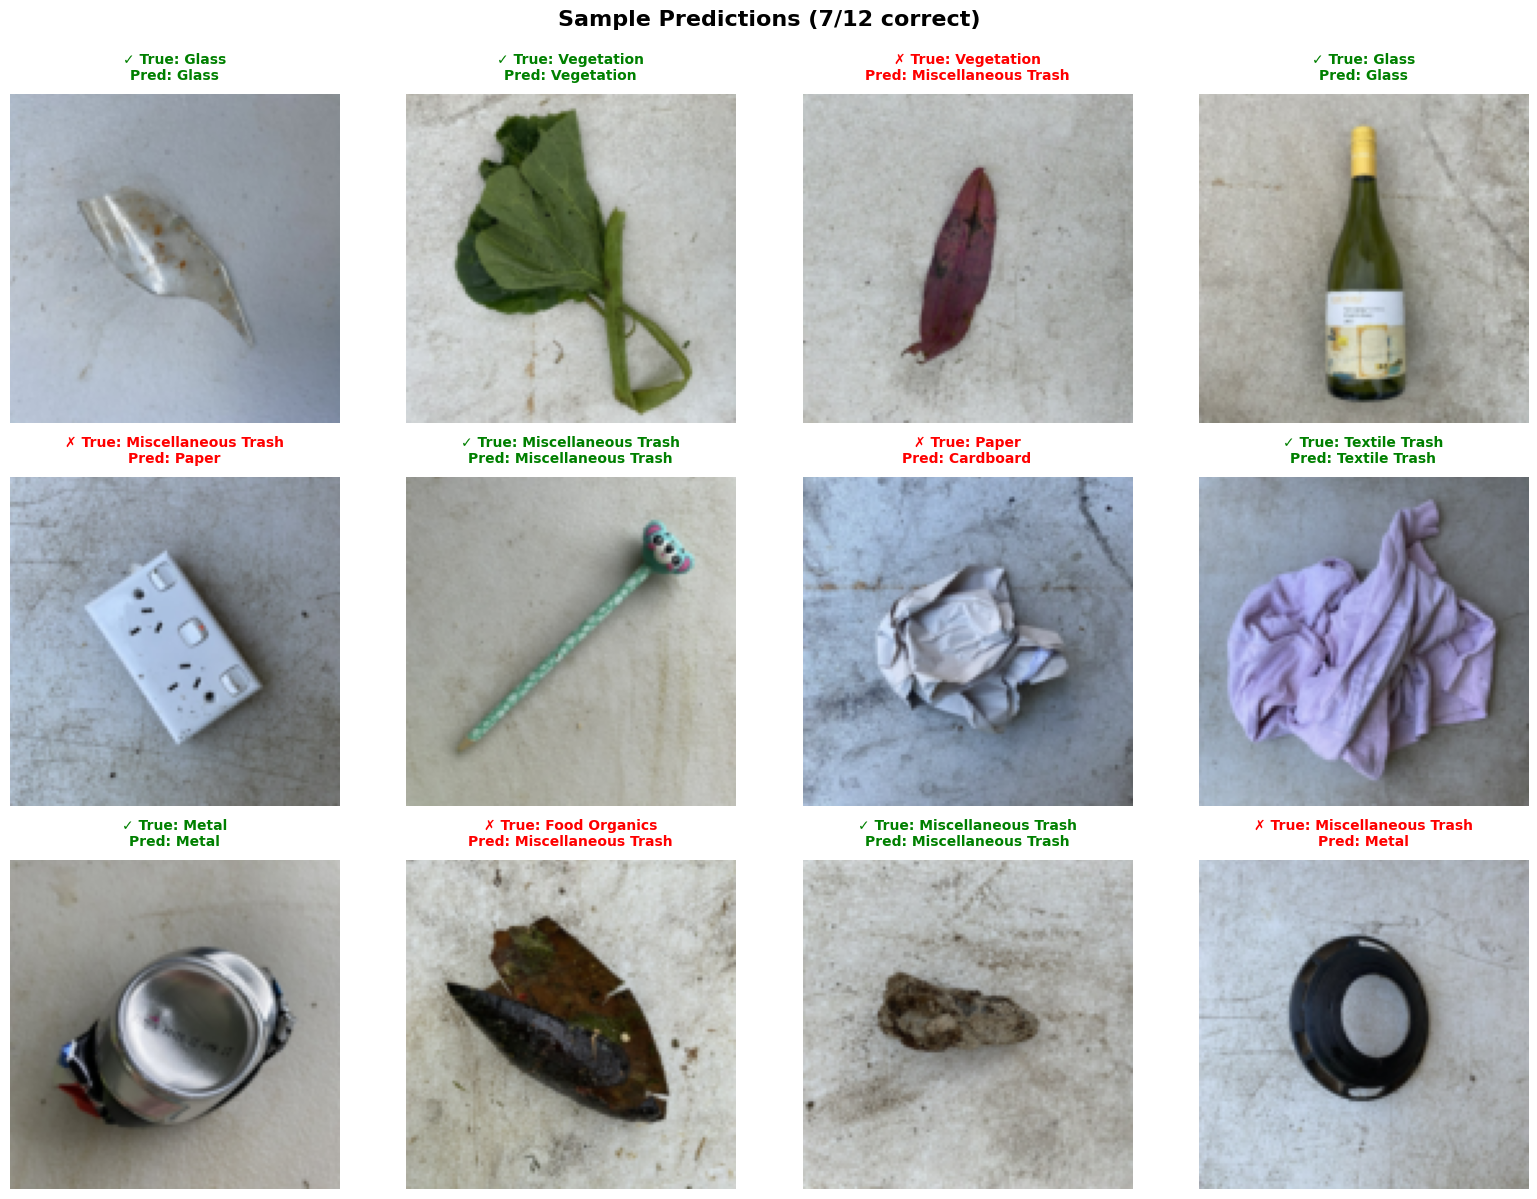

In [ ]:
def denormalize(tensor):
    """Denormalize image tensor for visualization"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    tensor = tensor * std + mean
    tensor = torch.clamp(tensor, 0, 1)
    return tensor

def show_predictions(model, test_dataset, num_samples=12):
    model.eval()
    indices = random.sample(range(len(test_dataset)), num_samples)

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.ravel()

    correct_count = 0

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, true_label = test_dataset[idx]
            image_input = image.unsqueeze(0).to(device)

            output = model(image_input)
            _, predicted = torch.max(output, 1)
            pred_label = predicted.item()

            img_display = denormalize(image).permute(1, 2, 0).cpu().numpy()

            axes[i].imshow(img_display)
            axes[i].axis('off')

            is_correct = (pred_label == true_label)
            if is_correct:
                correct_count += 1
                color = 'green'
                status = '✓'
            else:
                color = 'red'
                status = '✗'

            axes[i].set_title(f'{status} True: {classes[true_label]}\nPred: {classes[pred_label]}',
                            color=color, fontsize=10, fontweight='bold', pad=10)

    plt.suptitle(f'Sample Predictions ({correct_count}/{num_samples} correct)',
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

show_predictions(model, test_dataset, num_samples=12)
